In [461]:
from hikyuu.interactive import *

#创建一个从2022年4月1日开始的账户，初始资金100万元
my_tm = crtTM(date = Datetime(201204010000), init_cash = 1000000, cost_func=TC_FixedA(commission=0.0001, lowest_commission=5.0))
#不做仓位管理，全仓买进卖出
# my_mm = crtMM(MM_Nothing,{'auto-checkin':True})
my_mm = MM_Nothing()
# my_mm = MM_FixedCount()
#回测时间设定
query = Query(Datetime(201204010000), Datetime(202604010000), ktype = 'DAY', recover_type = Query.BACKWARD)

#回测标的限定
s = sm['sz300408']

In [474]:
def MultiFactorTrendFollowingSG(self, k):
    """
    多因子动量趋势跟踪策略 (中长期)
    逻辑：在牛市环境中，通过价格趋势、相对强度、动量、量价四维度筛选强势股，
          在趋势确立后的阶段性调整结束时入场，跟随趋势直至多维度转弱。
    
    参数:
        trend_period (int): 长期趋势均线周期，默认120日(半年线)
        momentum_period (int): 动量计算周期，默认60日
        strength_period (int): 相对强度计算周期，默认20日
        adx_threshold (float): ADX趋势强度阈值，默认25.0
        rsi_overbought (float): RSI超买阈值，默认70.0
        volume_ratio_th (float): 量比阈值，默认1.5
        atr_multiplier (float): ATR突破倍数，默认0.5
        stop_loss_atr (float): 基于ATR的移动止损倍数，默认2.0
    """
    # ========== 1. 参数获取 ==========
    p_trend = self.get_param("trend_period")
    p_momentum = self.get_param("momentum_period")
    p_strength = self.get_param("strength_period")
    p_adx_th = self.get_param("adx_threshold")
    p_rsi_ob = self.get_param("rsi_overbought")
    p_vr_th = self.get_param("volume_ratio_th")
    p_atr_mul = self.get_param("atr_multiplier")
    p_stop_atr = self.get_param("stop_loss_atr")
    
    # ========== 2. 数据准备 ==========
    c = CLOSE(k)
    h = HIGH(k)
    l = LOW(k)
    o = OPEN(k)
    v = VOL(k)
    
    # ========== 3. 指标计算 ==========
    # 3.1 趋势指标
    ma_short = MA(c, 20)      # 短期均线，用于跟踪
    ma_mid = MA(c, 60)        # 中期均线，用于趋势过滤
    ma_long = MA(c, p_trend)  # 长期均线，牛熊分界线
    
    # 计算ADX（趋势强度）
    # Hikyuu中可能没有直接ADX，使用DMI相关函数近似或自行计算
    # 这里使用一个简化版本：用收盘价与均线的绝对偏离度来衡量趋势强度
    trend_strength = ABS(c - ma_mid) / ma_mid * 100
    
    # 3.2 动量指标
    momentum = (c / REF(c, p_momentum) - 1) * 100  # N日涨幅
    rsi = RSI(c, 14)
    
    # 3.3 波动与突破
    atr = ATR(k, 14)  # 14日平均真实波幅
    high_n = HHV(h, 55)  # 55日高点（约一个季度）
    
    # 3.4 量价指标
    vol_ma = MA(v, 20)
    volume_ratio = v / REF(vol_ma, 1)  # 量比
    
    # ========== 4. 条件判断 ==========
    # 确保有足够数据
    if len(c) < max(p_trend, p_momentum) + 10:
        return
    
    for i in range(max(p_trend, p_momentum), len(k)):
        # 4.1 核心条件：必须在长期牛市格局中 (价格在年线上方)
        condition_trend = c[i] > ma_long[i]
        
        # 4.2 动量条件：中期动量强劲
        condition_momentum = momentum[i] > 5.0  # 过去N日涨幅大于5%
        
        # 4.3 趋势强度条件：有显著趋势
        condition_strength = trend_strength[i] > p_adx_th
        
        # 4.4 相对强度条件：个股表现强于自身中期均线
        # (更优解是强于指数，此处简化)
        condition_relative = c[i] > ma_mid[i] * 1.05  # 价格高于中期均线5%
        
        # 4.5 量价配合：上涨日需要放量确认
        condition_volume = (c[i] > o[i]) and (volume_ratio[i] > p_vr_th)
        
        # 4.6 入场时机：强势调整后再次启动
        # 条件：价格接近或轻微跌破短期均线后，再次放量上涨
        condition_entry = (l[i] <= ma_short[i] * 1.02) and (c[i] > ma_short[i])
        
        # ========== 5. 买入信号生成 ==========
        buy_cond = (condition_trend and condition_momentum and 
                   condition_strength and condition_relative and 
                   condition_volume and condition_entry)
        
        # RSI过滤：避免在极端超买时追高
        if i < len(rsi) and rsi[i] > 85:
            buy_cond = False
            
        if buy_cond:
            # 记录入场价格和ATR，用于止损
            self._add_buy_signal(k[i].datetime)
            # 可以在此处记录入场价和ATR，用于后续跟踪止损
            # 例如：self.entry_price = c[i]; self.entry_atr = atr[i]
            
        # ========== 6. 卖出信号生成 ==========
        # 6.1 趋势破位：价格跌破关键中期均线（如60日线）
        sell_cond1 = c[i] < ma_mid[i]
        
        # 6.2 动量衰竭：RSI从高位回落形成顶背离（简化：RSI下穿70）
        sell_cond2 = False
        if i > 0 and i < len(rsi):
            sell_cond2 = (rsi[i-1] > 70) and (rsi[i] < 70)
            
        # 6.3 移动止损（基于ATR）：从最高点回撤超过2倍ATR
        # 注意：这里需要维护持仓以来的最高价
        # if hasattr(self, 'highest_since_buy'):
        #     self.highest_since_buy = max(self.highest_since_buy, h[i])
        #     sell_cond3 = (c[i] < self.highest_since_buy - atr[i] * p_stop_atr)
        
        # 简化版：价格跌破短期均线且趋势强度减弱
        sell_cond3 = (c[i] < ma_short[i]) and (trend_strength[i] < p_adx_th)
        
        # 6.4 综合卖出条件
        sell_cond = sell_cond1 or sell_cond2 or sell_cond3
        
        if sell_cond:
            self._add_sell_signal(k[i].datetime)
            # 清理持仓记录
            # if hasattr(self, 'highest_since_buy'):
            #     del self.highest_since_buy


# ========== 7. 创建策略实例 ==========
# 注意：这是一个基础框架，实际使用前需进行充分回测和参数优化
trend_follow_sg = crtSG(
    MultiFactorTrendFollowingSG,
    {
        'trend_period': 120,
        'momentum_period': 60,
        'strength_period': 20,
        'adx_threshold': 25.0,
        'rsi_overbought': 80.0,
        'volume_ratio_th': 1.5,
        'atr_multiplier': 0.5,
        'stop_loss_atr': 2.0,'alternate':False, 'support_borrow_stock': True
    },
    '多因子动量趋势跟踪策略'
)


In [475]:
def SKDJDivergenceSG(self, k):
    """
    SKDJ背离策略
    参数说明:
    n: SKDJ周期参数，默认9
    m: K值平滑参数，默认3
    oversold: 超卖阈值，默认20
    overbought: 超买阈值，默认80
    lookback: 背离检测回溯周期，默认20
    """
    # 获取参数
    n = self.get_param("n")
    m = self.get_param("m")
    oversold = self.get_param("oversold")
    overbought = self.get_param("overbought")
    lookback = self.get_param("lookback")
    window = self.get_param("window")
    
    
    # 获取价格数据
    c = CLOSE(k)
    l = LOW(k)
    h = HIGH(k)

    lowv = LLV(l, n)
    highv = HHV(h, n)
    rsv = (c - lowv) / (highv - lowv) * 100
    rsv_slow = EMA(rsv, m)
    skdj_k = EMA(rsv_slow, m)

    # 使用find_phase_extreme_points函数获取阶段低点和高点
    # 这里使用lookback作为窗口参数
    phase_lows, phase_highs = find_phase_extreme_points(k, window=window, min_depth=0.01)
    
 # 确保有足够数据
    if len(c) < 30 or len(skdj_k) < 30:
        return
    
    # 存储最近的阶段低点和高点
    last_low_point = None
    last_high_point = None
    
    # 遍历K线
    for i in range(window*2, len(k)):
        # 获取当前值
        current_low = l[i]
        current_high = h[i]
        current_skdj_k = skdj_k[i] if i < len(skdj_k) else None
        
        if current_skdj_k is None:
            continue
        
        # 1. 更新最近的阶段低点
        for low_point in phase_lows:
            if low_point['index'] < i-4:
                if last_low_point is None or low_point['index'] > last_low_point['index']:
                    last_low_point = low_point.copy()
                    if low_point['index'] < len(skdj_k):
                        last_low_point['skdj_k'] = skdj_k[low_point['index']]
        
        # 2. 更新最近的阶段高点
        for high_point in phase_highs:
            if high_point['index'] < i:
                if last_high_point is None or high_point['index'] > last_high_point['index']:
                    last_high_point = high_point.copy()
                    if high_point['index'] < len(skdj_k):
                        last_high_point['skdj_k'] = skdj_k[high_point['index']]
        
        # 3. 底背离买入信号
        if (last_low_point is not None and 
            'skdj_k' in last_low_point and
            current_skdj_k < oversold):
            
            # 价格创新低
            price_new_low = current_low < last_low_point['price']
            
            # SKDJ没有创新低
            skdj_not_new_low = current_skdj_k > last_low_point['skdj_k']
            
            # SKDJ开始反转
            skdj_reverse = False
            if i >= 2 and i < len(skdj_k):
                skdj_reverse = skdj_k[i] > skdj_k[i-1]
            
            if price_new_low and skdj_not_new_low and skdj_reverse:
                self._add_buy_signal(k[i].datetime)
        
        # 4. 顶背离卖出信号
        if (last_high_point is not None and 
            'skdj_k' in last_high_point and
            current_skdj_k > overbought):
            
            # 价格创新高
            price_new_high = current_high > last_high_point['price']
            
            # SKDJ没有创新高
            skdj_not_new_high = current_skdj_k < last_high_point['skdj_k']
            
            # SKDJ开始反转
            skdj_reverse = False
            if i >= 2 and i < len(skdj_k):
                skdj_reverse = skdj_k[i] < skdj_k[i-1]
            
            if price_new_high and skdj_not_new_high and skdj_reverse:
                self._add_sell_signal(k[i].datetime)




# 创建策略实例
my_sg = crtSG(SKDJDivergenceSG, 
              {'n': 9, 'm': 3, 'oversold': 55, 'overbought': 50, 'lookback': 20, 'window':4 ,'alternate':False, 'support_borrow_stock': True}, 
              'SKDJ背离策略')

In [476]:
#进行回测
sys = SYS_Simple(tm = my_tm, mm = my_mm, sg = trend_follow_sg)
sys.run(s, query)

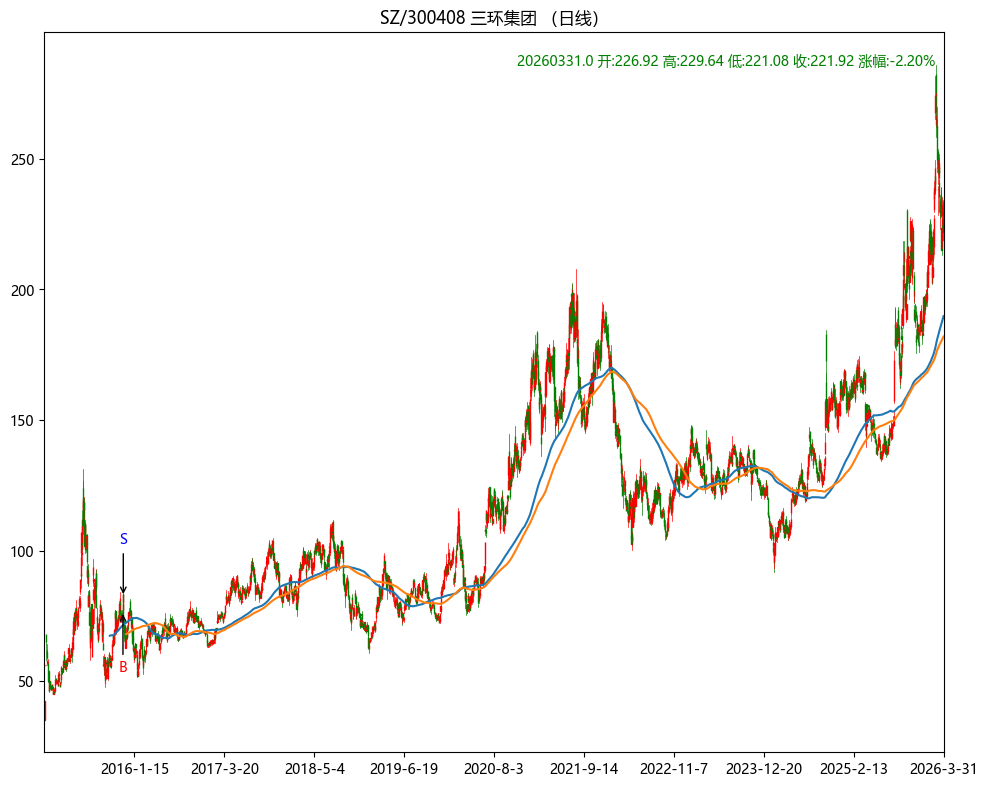

2026-04-27 00:00:00.015 [HKU-I] - start reload ... (StockManager.cpp:434)
2026-04-27 00:00:00.033 [HKU-I] - 加载市场信息…… (StockManager.cpp:795)
2026-04-27 00:00:00.038 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:812)
2026-04-27 00:00:00.041 [HKU-I] - 加载证券信息…… (StockManager.cpp:693)
2026-04-27 00:00:03.021 [HKU-I] - 加载权息数据…… (StockManager.cpp:829)
2026-04-27 00:00:03.276 [HKU-I] - 加载板块信息…… (StockManager.cpp:184)
2026-04-27 00:00:03.402 [HKU-I] - 加载K线数据…… (StockManager.cpp:188)
2026-04-27 00:00:03.405 [HKU-I] - 预加载 month K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-27 00:00:03.408 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-27 00:00:03.410 [HKU-I] - 预加载 week K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-27 00:00:03.413 [HKU-I] - 预加载 year K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-27 00:00:03.415 [HKU-I] - 3.38 秒数据加载完毕. (StockManager.cpp:198)


In [477]:
sys.plot()
MA(CLOSE(sys.to), n = 200).plot(new=False)
MA(CLOSE(sys.to), n = 250).plot(new=False)
# ax1,ax2 = create_figure(2)
# sys.plot(axes=ax1)

#在第二个坐标轴中绘制艾尔德力度指标
# skdj_k = MA(KDJ(s.get_kdata(query))[0],n=3)
# skdj_k.plot(axes=ax2, legend_on=True)

# n=9 
# m=3
# k =  s.get_kdata(query)
# c = CLOSE(k)
# l = LOW(k)
# h = HIGH(k)
# lowv = LLV(l, n)
# highv = HHV(h, n)
# rsv = (c - lowv) / (highv - lowv) * 100
# rsv_slow = EMA(rsv, m)
# skdj_k = EMA(rsv_slow, m)

# skdj_k.plot(axes=ax2, legend_on=True)

<Axes: title={'center': '账户(SYS) 累积收益率'}>

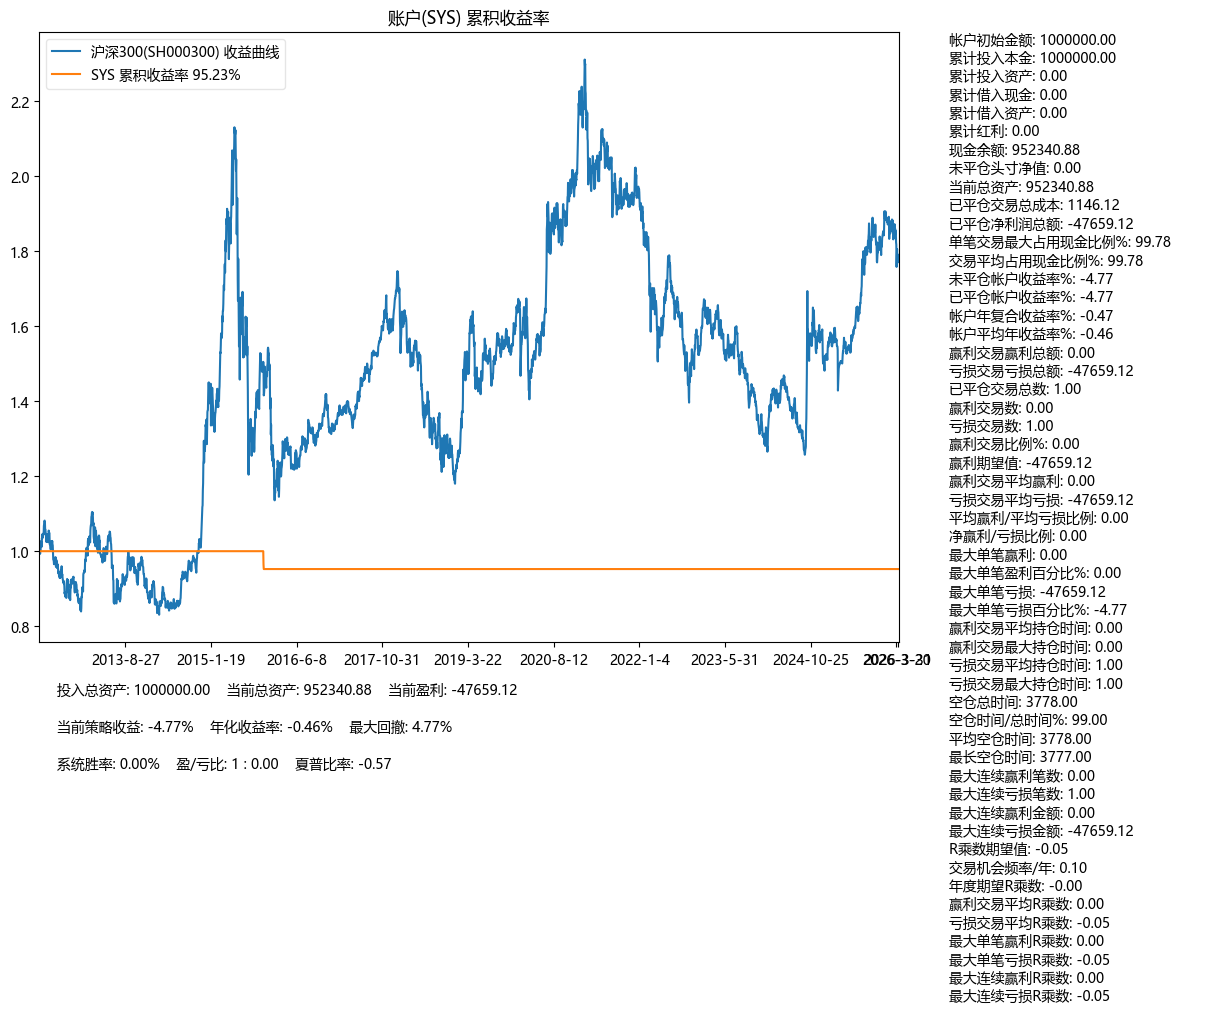

In [473]:
sys.performance()

In [469]:
skdj_k

Indicator{
  name: EMA
  size: 3814
  discard: 0
  stock: 
  result sets: 1
  params: params[n(int): 3, ]
  is python object: False
  formula: EMA(EMA(CLOSE - LLV(LOW) / HHV(HIGH) - LLV(LOW) * CVAL(CLOSE - LLV(LOW) / HHV(HIGH) - LLV(LOW))))
  values0: [46.0317, 49.2063, 47.619, ..., 42.2392, 53.3437, 50.6913]
}

In [319]:
import pandas as pd
def calTotal(blk, q):
    per = Performance()
    s_name = []
    s_code = []
    x = []
    for stk in blk:
        sys.run(stk, q)
        per.statistics(my_tm, Datetime.now())
        s_name.append(stk.name)
        s_code.append(stk.market_code)
        x.append(per["当前总资产"])
    return pd.DataFrame({'代码': s_code, '股票': s_name, '当前总资产': x})

%time data = calTotal(blocka, query)

2026-04-24 22:11:45.548 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-24 22:11:45.550 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-24 22:12:09.277 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-24 22:12:09.278 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-24 22:12:14.815 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-24 22:12:14.816 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
CPU times: total: 58.2 s
Wall time: 58.5 s


In [320]:
data.sort_values(['当前总资产'])

,代码,股票,当前总资产
1452,SH600696,*ST岩石,54471.78
3130,SZ002231,*ST奥维,179111.87
2762,SZ000638,*ST万方,214260.84
79,SH600355,*ST精伦,225129.82
1720,SH603363,傲农生物,231562.91
...,...,...,...
121,SH603268,松发股份,13139327.29
1886,SH603009,北特科技,13546408.22
423,SH600105,永鼎股份,13552113.80
147,SH603256,宏和科技,14010805.41


<Axes: ylabel='Frequency'>

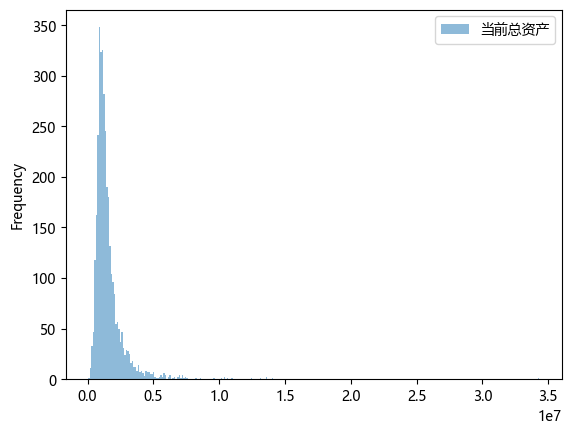

In [322]:
data.plot.hist(bins=300, alpha=0.5)

In [ ]:
for stk in blocka:
    print(stk)

In [11]:
# 获取K线数据
stock = sm['sh000001']
k = stock.get_kdata(Query(-600))

def find_phase_low_points_with_confirmation(k, window=5, min_depth=0.01):
    """
    增强版本：带确认条件的阶段低点寻找
    
    参数：
    k: K线数据
    window: 时间窗口大小
    min_depth: 最小深度（相对周围价格的百分比）
    
    返回：
    包含阶段低点信息的列表
    """
    # 获取价格序列
    low_prices = LOW(k)
    high_prices = HIGH(k)
    close_prices = CLOSE(k)
    
    n = len(k)
    phase_lows = []
    
    for i in range(window, n - window):
        # 获取窗口
        start_idx = i - window
        end_idx = i + window + 1
        
        # 当前最低价
        current_low = low_prices[i]
        
        # 条件1：是窗口内的最低点
        window_lows = low_prices[start_idx:end_idx]
        if current_low > min(window_lows):
            continue
        
        # 条件2：检查唯一性（严格小于窗口内其他所有最低价）
        is_unique_min = True
        for j in range(start_idx, end_idx):
            if j != i and low_prices[j] <= current_low:
                is_unique_min = False
                break
        
        if not is_unique_min:
            continue
        
        # 条件3：最小深度要求
        # 计算窗口内除当前点外的平均最低价
        other_lows = [low_prices[j] for j in range(start_idx, end_idx) if j != i]
        avg_other_lows = sum(other_lows) / len(other_lows) if other_lows else current_low
        
        # 计算深度
        depth = (avg_other_lows - current_low) / avg_other_lows
        if depth < min_depth:
            continue
        
        # 条件4：价格形态确认（可选）
        # 检查是否形成V形底：前几日下跌，后几日上涨
        is_v_shape = True
        for offset in range(1, 4):  # 检查前后3日
            if i - offset >= 0 and i + offset < n:
                # 前几日应该下跌或持平
                if close_prices[i-offset] < current_low:
                    is_v_shape = False
                    break
                # 后几日应该上涨
                if close_prices[i+offset] < current_low:
                    is_v_shape = False
                    break
        
        # 记录符合条件的阶段低点
        phase_lows.append({
            'index': i,
            'date': k[i].datetime,
            'low_price': float(current_low),
            'avg_surrounding': float(avg_other_lows),
            'depth_percent': float(depth * 100),
            'is_v_shape': is_v_shape,
            'window_size': 2 * window + 1
        })
    
    return phase_lows

find_phase_low_points_with_confirmation(k)

[{'index': 37,
  'date': Datetime(2023,12,21,0,0,0,0,0),
  'low_price': 2882.02,
  'avg_surrounding': 2914.15,
  'depth_percent': 1.102551344302802,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 59,
  'date': Datetime(2024,1,23,0,0,0,0,0),
  'low_price': 2724.16,
  'avg_surrounding': 2818.2110000000002,
  'depth_percent': 3.3372589916085196,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 68,
  'date': Datetime(2024,2,5,0,0,0,0,0),
  'low_price': 2635.09,
  'avg_surrounding': 2793.7560000000003,
  'depth_percent': 5.679307713343619,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 80,
  'date': Datetime(2024,2,29,0,0,0,0,0),
  'low_price': 2943.62,
  'avg_surrounding': 2990.162,
  'depth_percent': 1.556504296422733,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 100,
  'date': Datetime(2024,3,28,0,0,0,0,0),
  'low_price': 2984.12,
  'avg_surrounding': 3034.678,
  'depth_percent': 1.6660087165755308,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 11

In [18]:
def find_phase_extreme_points(k, window=5, min_depth=0.01):
    """
    增强版本：带确认条件的阶段低点和阶段高点寻找
    
    参数：
    k: K线数据
    window: 时间窗口大小
    min_depth: 最小深度（相对周围价格的百分比）
    
    返回：
    (phase_lows, phase_highs) 元组，包含阶段低点和阶段高点信息的列表
    """
    # 获取价格序列
    low_prices = LOW(k)
    high_prices = HIGH(k)
    close_prices = CLOSE(k)
    
    n = len(k)
    phase_lows = []
    phase_highs = []
    
    for i in range(window, n - window):
        # 获取窗口
        start_idx = i - window
        end_idx = i + window + 1
        
        # 1. 阶段低点检测
        # 当前最低价
        current_low = low_prices[i]
        
        # 条件1：是窗口内的最低点
        window_lows = low_prices[start_idx:end_idx]
        if current_low > min(window_lows):
            low_is_extreme = False
        else:
            # 条件2：检查唯一性（严格小于窗口内其他所有最低价）
            is_unique_min = True
            for j in range(start_idx, end_idx):
                if j != i and low_prices[j] <= current_low:
                    is_unique_min = False
                    break
            
            if not is_unique_min:
                low_is_extreme = False
            else:
                # 条件3：最小深度要求
                # 计算窗口内除当前点外的平均最低价
                other_lows = [low_prices[j] for j in range(start_idx, end_idx) if j != i]
                avg_other_lows = sum(other_lows) / len(other_lows) if other_lows else current_low
                
                # 计算深度
                depth = (avg_other_lows - current_low) / avg_other_lows
                if depth < min_depth:
                    low_is_extreme = False
                else:
                    # 条件4：价格形态确认（可选）
                    # 检查是否形成V形底：前几日下跌，后几日上涨
                    is_v_shape = True
                    for offset in range(1, 4):  # 检查前后3日
                        if i - offset >= 0 and i + offset < n:
                            # 前几日应该下跌或持平
                            if close_prices[i-offset] < current_low:
                                is_v_shape = False
                                break
                            # 后几日应该上涨
                            if close_prices[i+offset] < current_low:
                                is_v_shape = False
                                break
                    
                    low_is_extreme = True
        
        # 2. 阶段高点检测
        # 当前最高价
        current_high = high_prices[i]
        
        # 条件1：是窗口内的最高点
        window_highs = high_prices[start_idx:end_idx]
        if current_high < max(window_highs):
            high_is_extreme = False
        else:
            # 条件2：检查唯一性（严格大于窗口内其他所有最高价）
            is_unique_max = True
            for j in range(start_idx, end_idx):
                if j != i and high_prices[j] >= current_high:
                    is_unique_max = False
                    break
            
            if not is_unique_max:
                high_is_extreme = False
            else:
                # 条件3：最小深度要求
                # 计算窗口内除当前点外的平均最高价
                other_highs = [high_prices[j] for j in range(start_idx, end_idx) if j != i]
                avg_other_highs = sum(other_highs) / len(other_highs) if other_highs else current_high
                
                # 计算深度
                depth = (current_high - avg_other_highs) / avg_other_highs
                if depth < min_depth:
                    high_is_extreme = False
                else:
                    # 条件4：价格形态确认（可选）
                    # 检查是否形成倒V形顶：前几日上涨，后几日下跌
                    is_inverse_v_shape = True
                    for offset in range(1, 4):  # 检查前后3日
                        if i - offset >= 0 and i + offset < n:
                            # 前几日应该上涨
                            if close_prices[i-offset] > current_high:
                                is_inverse_v_shape = False
                                break
                            # 后几日应该下跌
                            if close_prices[i+offset] > current_high:
                                is_inverse_v_shape = False
                                break
                    
                    high_is_extreme = True
        
        # 记录符合条件的阶段低点
        if low_is_extreme:
            # 计算周围平均价格（用于深度计算）
            other_lows = [low_prices[j] for j in range(start_idx, end_idx) if j != i]
            avg_other_lows = sum(other_lows) / len(other_lows) if other_lows else current_low
            
            phase_lows.append({
                'index': i,
                'date': k[i].datetime,
                'price': float(current_low),  # 低点价格
                'avg_surrounding': float(avg_other_lows),
                'depth_percent': float(((avg_other_lows - current_low) / avg_other_lows) * 100),
                'is_v_shape': is_v_shape,
                'window_size': 2 * window + 1,
                'type': 'low'  # 标记为低点
            })
        
        # 记录符合条件的阶段高点
        if high_is_extreme:
            # 计算周围平均价格（用于深度计算）
            other_highs = [high_prices[j] for j in range(start_idx, end_idx) if j != i]
            avg_other_highs = sum(other_highs) / len(other_highs) if other_highs else current_high
            
            phase_highs.append({
                'index': i,
                'date': k[i].datetime,
                'price': float(current_high),  # 高点价格
                'avg_surrounding': float(avg_other_highs),
                'depth_percent': float(((current_high - avg_other_highs) / avg_other_highs) * 100),
                'is_inverse_v_shape': is_inverse_v_shape,
                'window_size': 2 * window + 1,
                'type': 'high'  # 标记为高点
            })
    
    return phase_lows, phase_highs


# 为了保持向后兼容，可以创建一个包装函数
def find_phase_low_points_with_confirmation(k, window=5, min_depth=0.01):
    """
    增强版本：带确认条件的阶段低点寻找
    
    参数：
    k: K线数据
    window: 时间窗口大小
    min_depth: 最小深度（相对周围价格的百分比）
    
    返回：
    包含阶段低点信息的列表
    """
    phase_lows, _ = find_phase_extreme_points(k, window, min_depth)
    return phase_lows



find_phase_extreme_points(k)

([{'index': 37,
   'date': Datetime(2023,12,21,0,0,0,0,0),
   'price': 2882.02,
   'avg_surrounding': 2914.15,
   'depth_percent': 1.102551344302802,
   'is_v_shape': True,
   'window_size': 11,
   'type': 'low'},
  {'index': 59,
   'date': Datetime(2024,1,23,0,0,0,0,0),
   'price': 2724.16,
   'avg_surrounding': 2818.2110000000002,
   'depth_percent': 3.3372589916085196,
   'is_v_shape': True,
   'window_size': 11,
   'type': 'low'},
  {'index': 68,
   'date': Datetime(2024,2,5,0,0,0,0,0),
   'price': 2635.09,
   'avg_surrounding': 2793.7560000000003,
   'depth_percent': 5.679307713343619,
   'is_v_shape': True,
   'window_size': 11,
   'type': 'low'},
  {'index': 80,
   'date': Datetime(2024,2,29,0,0,0,0,0),
   'price': 2943.62,
   'avg_surrounding': 2990.162,
   'depth_percent': 1.556504296422733,
   'is_v_shape': True,
   'window_size': 11,
   'type': 'low'},
  {'index': 100,
   'date': Datetime(2024,3,28,0,0,0,0,0),
   'price': 2984.12,
   'avg_surrounding': 3034.678,
   'depth_pe

In [465]:
def HotSpotFollowSG_Enhanced(self, k):
    """
    增强版市场热点跟随策略 - 支持多股票组合
    
    参数说明:
    新增:
    max_positions: 最大持仓数量，默认5
    rebalance_days: 调仓周期，默认5
    min_score: 最小热点得分阈值，默认1.2
    """
    # 基础参数
    momentum_days = self.get_param("momentum_days")
    volume_ratio_threshold = self.get_param("volume_ratio_threshold")
    max_positions = self.get_param("max_positions")
    rebalance_days = self.get_param("rebalance_days")
    min_score = self.get_param("min_score")
    
    # 获取价格和成交量
    c = CLOSE(k)
    h = HIGH(k)
    v = VOL(k)
    
    # 计算技术指标
    momentum_returns = (c / REF(c, momentum_days) - 1) * 100
    avg_volume = MA(v, momentum_days)
    volume_ratio = v / avg_volume
    rsi = RSI(c, 14)
    ma20 = MA(c, 20)
    relative_strength = c / ma20 * 100
    high_20 = HHV(h, 20)
    is_breakout = c > REF(high_20, 1)
    
    # 初始化
    if not hasattr(self, 'portfolio'):
        self.portfolio = {}  # 持仓组合
        self.last_rebalance = None
        self.trade_log = []
    
    if len(c) < 30:
        return
    
    for i in range(20, len(k)):
        current_date = k[i].datetime
        current_price = c[i]
        
        # 计算热点得分
        score = 0
        
        # 动量得分
        if i < len(momentum_returns) and momentum_returns[i] > 8:
            score += 0.3
        if i < len(momentum_returns) and momentum_returns[i] > 15:
            score += 0.2
        
        # 量比得分
        if i < len(volume_ratio) and volume_ratio[i] > volume_ratio_threshold:
            score += 0.25
        if i < len(volume_ratio) and volume_ratio[i] > volume_ratio_threshold * 2:
            score += 0.15
        
        # 相对强度得分
        if i < len(relative_strength) and relative_strength[i] > 105:
            score += 0.1
        
        # 突破得分
        if i < len(is_breakout) and is_breakout[i]:
            score += 0.1
        
        # RSI过滤
        if i < len(rsi) and rsi[i] > 80:
            score -= 0.3  # 超买惩罚
        
        # 买入条件
        if (score >= min_score and 
            i < len(volume_ratio) and volume_ratio[i] > volume_ratio_threshold and
            len(self.portfolio) < max_positions):
            
            # 检查是否需要调仓
            rebalance_needed = False
            if self.last_rebalance is None:
                rebalance_needed = True
            else:
                days_since_rebalance = (current_date - self.last_rebalance).days
                rebalance_needed = (days_since_rebalance >= rebalance_days)
            
            if rebalance_needed or score > 1.5:  # 高分优先
                # 生成买入信号
                stock_code = k.get_stock().market_code
                
                self.portfolio[stock_code] = {
                    'buy_date': current_date,
                    'buy_price': current_price,
                    'score': score,
                    'entry_index': i
                }
                
                self._add_buy_signal(current_date)
                self.last_rebalance = current_date
                
                self.trade_log.append({
                    'date': current_date,
                    'action': 'BUY',
                    'stock': stock_code,
                    'price': current_price,
                    'score': score,
                    'portfolio_size': len(self.portfolio)
                })
        
        # 卖出检查
        stocks_to_sell = []
        for stock_code, position in list(self.portfolio.items()):
            buy_price = position['buy_price']
            current_return = (current_price - buy_price) / buy_price
            
            # 止盈止损
            if current_return >= 0.15 or current_return <= -0.08:
                stocks_to_sell.append(stock_code)
            
            # 热点退潮
            elif score < 0.5:  # 当前热点得分低
                hold_days = (current_date - position['buy_date']).days
                if hold_days >= 3:
                    stocks_to_sell.append(stock_code)
        
        # 执行卖出
        for stock_code in stocks_to_sell:
            position = self.portfolio.pop(stock_code)
            profit_pct = (current_price - position['buy_price']) / position['buy_price'] * 100
            
            self._add_sell_signal(current_date)
            
            self.trade_log.append({
                'date': current_date,
                'action': 'SELL',
                'stock': stock_code,
                'price': current_price,
                'profit_pct': profit_pct,
                'hold_days': (current_date - position['buy_date']).days,
                'alternate':False, 
                'support_borrow_stock': True
            })


# 创建增强版策略
hotspot_enhanced_sg = crtSG(HotSpotFollowSG_Enhanced,
    {
        'momentum_days': 5,
        'volume_ratio_threshold': 2.0,
        'max_positions': 5,
        'rebalance_days': 5,
        'min_score': 0.7
    },
    '市场热点跟随策略(增强版)'
)



In [13]:
from hikyuu.interactive import *
#回测时间设定
query = Query(Datetime(201901010000), Datetime(202204010000), ktype = 'DAY', recover_type = Query.BACKWARD)

#回测标的限定


kdata is None


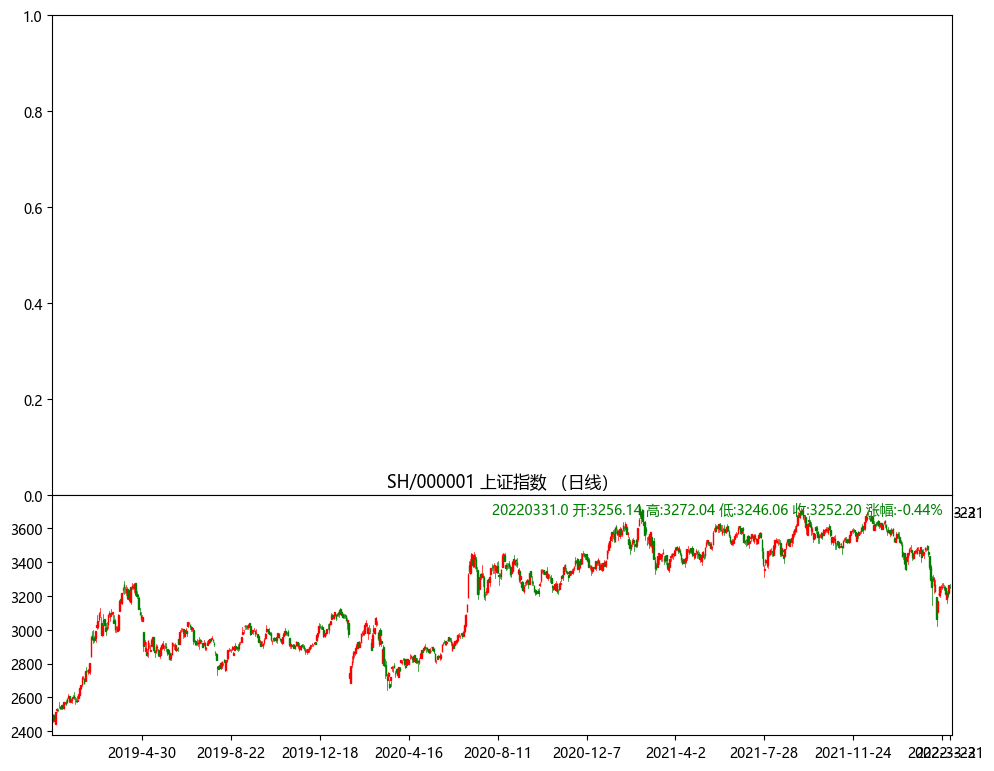

2026-05-26 00:00:00.008 [HKU-I] - start reload ... (StockManager.cpp:434)
2026-05-26 00:00:00.022 [HKU-I] - 加载市场信息…… (StockManager.cpp:795)
2026-05-26 00:00:00.026 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:812)
2026-05-26 00:00:00.028 [HKU-I] - 加载证券信息…… (StockManager.cpp:693)
2026-05-26 00:00:02.340 [HKU-I] - 加载权息数据…… (StockManager.cpp:829)
2026-05-26 00:00:02.620 [HKU-I] - 加载板块信息…… (StockManager.cpp:184)
2026-05-26 00:00:02.762 [HKU-I] - 加载K线数据…… (StockManager.cpp:188)
2026-05-26 00:00:02.765 [HKU-I] - 预加载 month K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-05-26 00:00:02.766 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-05-26 00:00:02.769 [HKU-I] - 预加载 week K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-05-26 00:00:02.771 [HKU-I] - 预加载 year K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-05-26 00:00:02.773 [HKU-I] - 2.75 秒数据加载完毕. (StockManager.cpp:198)


In [27]:
k =  sm['sh588200'].get_kdata(query)
k1 = sm['sh000001'].get_kdata(query)

ax1,ax2 = create_figure(2)
k.plot(axes=ax1)
k1.plot(axes=ax2)

In [26]:
sm.get_block_list()

[Block(指数板块, 创业板创新指数, 100),
 Block(指数板块, 商业指数, 170),
 Block(指数板块, 深信用债, 0),
 Block(指数板块, 上证指数, 2248),
 Block(指数板块, 上证民企, 50),
 Block(指数板块, 巨潮中盘, 270),
 Block(指数板块, 上证央企, 50),
 Block(指数板块, A股指数, 2207),
 Block(指数板块, 180治理, 99),
 Block(指数板块, 工业指数, 1689),
 Block(指数板块, 上证公用, 30),
 Block(指数板块, 区块链50, 50),
 Block(指数板块, B股指数, 41),
 Block(指数板块, 上证地企, 50),
 Block(指数板块, CBN-兴全, 100),
 Block(指数板块, 商务指数, 49),
 Block(指数板块, 上证材料, 50),
 Block(指数板块, 地产指数, 35),
 Block(指数板块, 公用指数, 139),
 Block(指数板块, 超大盘, 20),
 Block(指数板块, 深证100, 100),
 Block(指数板块, 综合指数, 226),
 Block(指数板块, 沪投资品, 50),
 Block(指数板块, 红利指数, 50),
 Block(指数板块, 上证380, 379),
 Block(指数板块, 责任指数, 99),
 Block(指数板块, 上证180, 180),
 Block(指数板块, 基金指数, 0),
 Block(指数板块, 国证2000, 1159),
 Block(指数板块, 中证A500, 500),
 Block(指数板块, 上证50, 50),
 Block(指数板块, 创精选88, 88),
 Block(指数板块, 新综指, 2206),
 Block(指数板块, 全R成长, 379),
 Block(指数板块, 上证商品, 50),
 Block(指数板块, 小盘成长, 166),
 Block(指数板块, 180金融, 43),
 Block(指数板块, 中盘价值, 100),
 Block(指数板块, 180高贝, 60),
 Block(指数板块, 治理指数, 299),
 Bl